CGRE (new tables from Louisa):

- Transfer nucleotide to aminos → aa genotypes
- Get mean of means and sum of stds (as for 1 amino can be several nucleotides)
- Take delta from wt
- Recount epistasis like Olga said

4 cgre variants in total.

In [1]:
import pandas as pd
import numpy as np

def table_parser(df):
    # Group by aa_genotype
    grouped = df.groupby("aa_genotype")
    # Calculate the mean brightness and standard deviation of brightness
    result = grouped[["brightness", "brightness_stdev"]].apply(
    lambda group: pd.Series({
        "brightness": group["brightness"].mean(),
        "brightness_stdev": np.sqrt(np.sum(group["brightness_stdev"] ** 2)) / len(group)
    })
    ).reset_index()
    # Calculate delta from wt and remove it 
    wt_brightness = result.loc[result["aa_genotype"] == "wt", "brightness"].values[0]
    wt_brightness_stdev = result.loc[result["aa_genotype"] == "wt", "brightness_stdev"].values[0]
    result["brightness"] = result["brightness"] - wt_brightness
    result["brightness_stdev"] = np.sqrt(result["brightness_stdev"] ** 2 + wt_brightness_stdev ** 2)
    result = result[~result["aa_genotype"].str.contains("wt", case=False, na=False)].reset_index(drop=True)
    # Calculate the number of mutations
    result["num_mutations"] = result["aa_genotype"].apply(lambda x: len(x.split(":")))
    return result

In [6]:
import os
import pandas as pd

directory = "data/errors_cgre"

for file in os.listdir(directory):
    file_path = os.path.join(directory, file)
    name = file.split("_")[3]
    df = pd.read_csv(file_path)
    df = table_parser(df)

    singles = df[df['num_mutations'] == 1].copy()
    multi = df[df['num_mutations'] > 1].copy()

    # Explicitly create new columns on a copy
    multi["sum_brightness"] = pd.NA
    multi["valid"] = pd.NA

    for i, row in multi.iterrows():
        muts = row["aa_genotype"].split(":")
        sum_brightness = 0
        missing = False

        for mut in muts:
            match = singles[singles["aa_genotype"] == mut]
            if match.empty:
                missing = True
                break
            sum_brightness += match["brightness"].values[0]

        if missing:
            continue

        multi.loc[i, "sum_brightness"] = sum_brightness

        # Compute sum of standard deviations
        sum_errors = sum(
            singles[singles["aa_genotype"] == mut]["brightness_stdev"].values[0] for mut in muts
        )

        # Apply epistasis condition
        is_valid = abs(row["brightness"] - sum_brightness) > sum_errors
        multi.loc[i, "valid"] = is_valid

    # Save result
    multi.to_csv(f"data/errors_cgre/{name}_to_plot.csv", index=False)

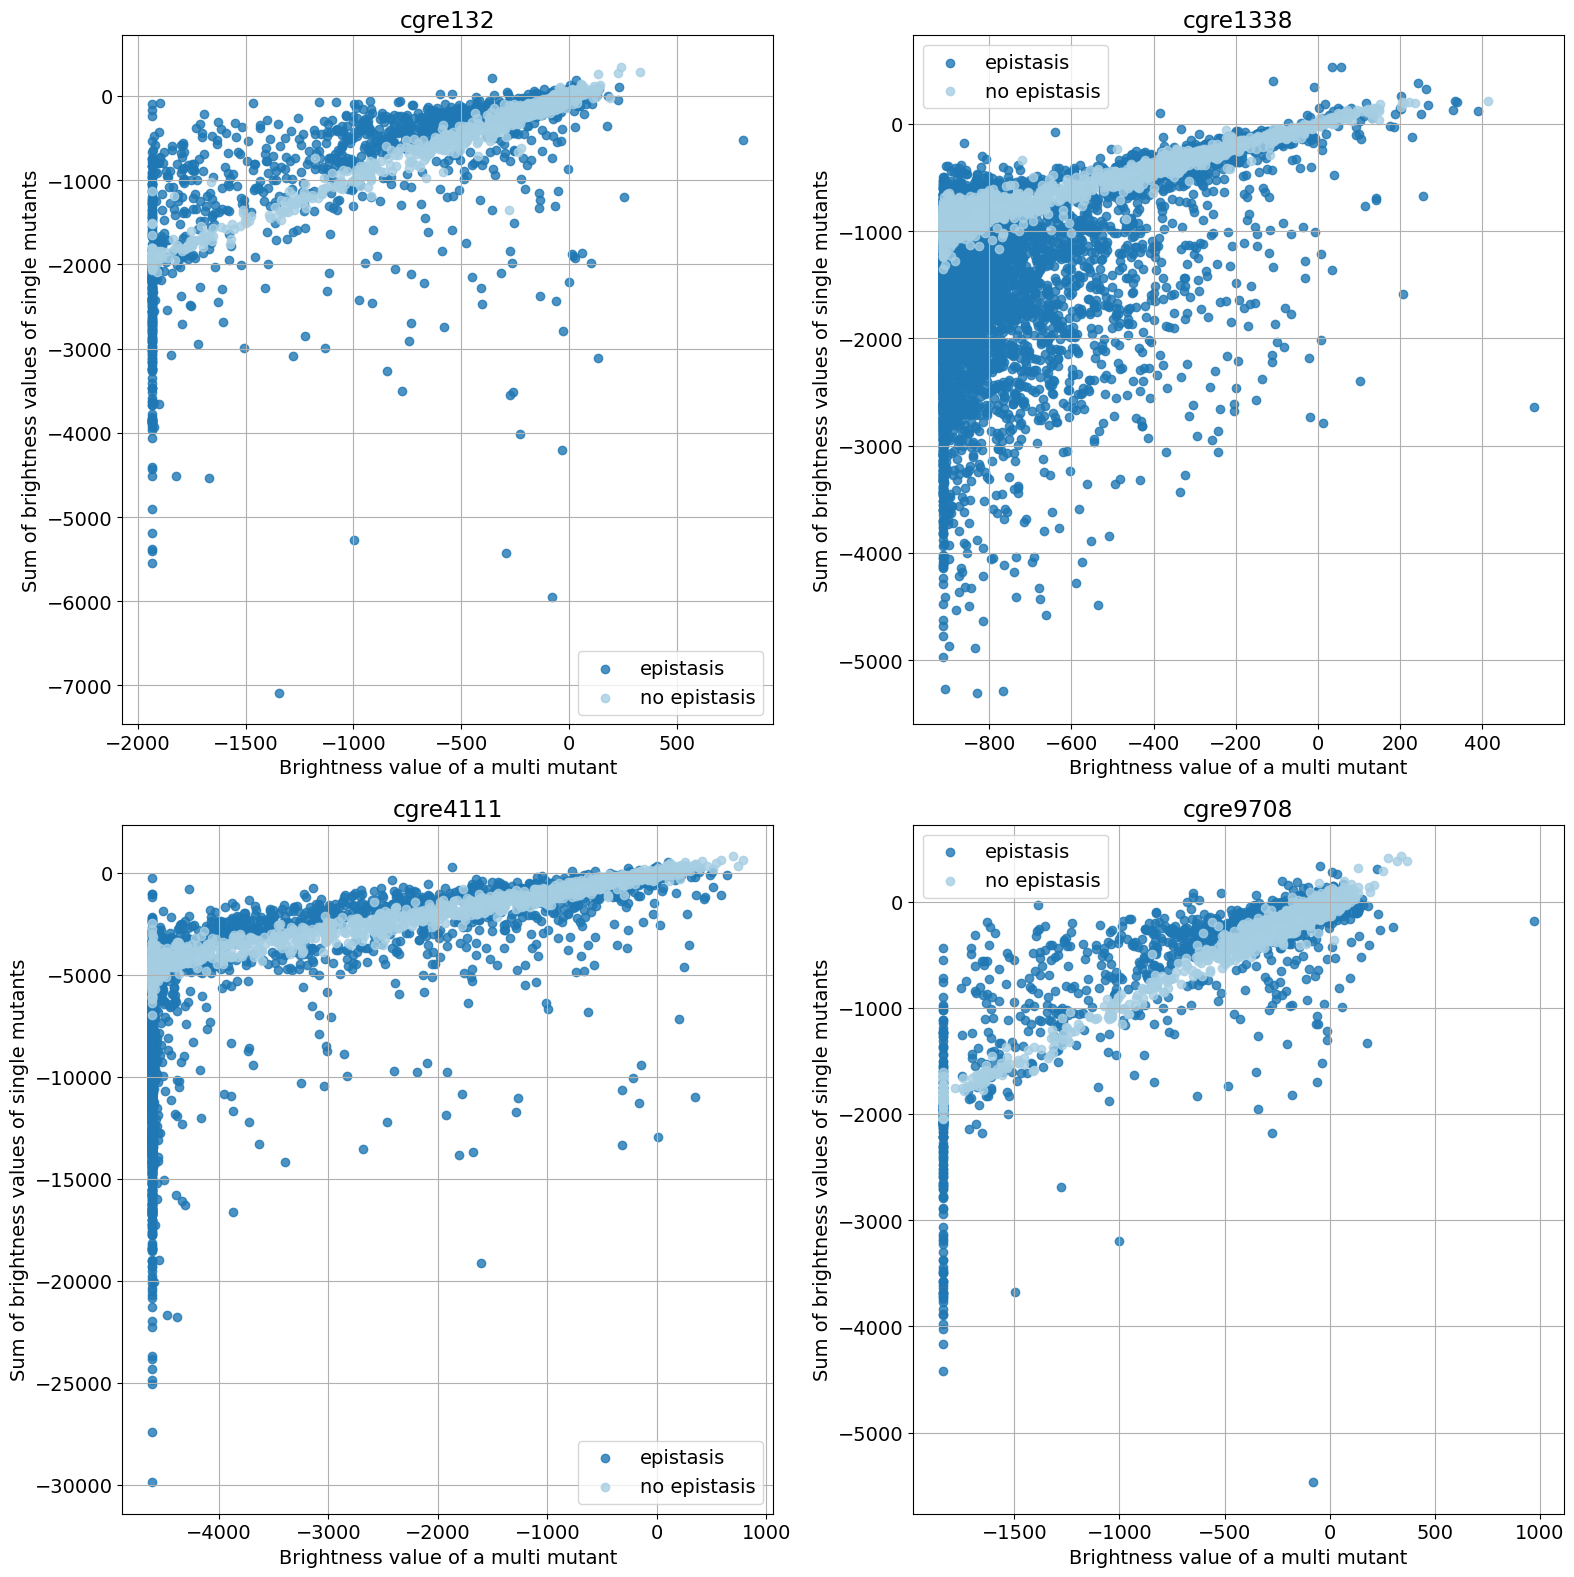

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 14})
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 16))

directory = "data/errors_cgre"
files = ["cgre132_to_plot.csv", "cgre1338_to_plot.csv",
         "cgre4111_to_plot.csv", "cgre9708_to_plot.csv"]
for index, file in enumerate(files):
    file_path = os.path.join(directory, file)
    name = file.split("_")[0]
    
    df = pd.read_csv(file_path)
    x = df[df["valid"] == True]['brightness'].values
    y = df[df["valid"] == True]['sum_brightness'].values
    distinct_x = df[df["valid"] == False]['brightness'].values
    distinct_y = df[df["valid"] == False]['sum_brightness'].values

    i = index // 2
    j = index % 2
    cmap = plt.get_cmap('Paired')
    axes[i, j].scatter(x, y, color=cmap(1), alpha=0.8, label='epistasis')
    axes[i, j].scatter(distinct_x, distinct_y, color=cmap(0), alpha=0.8, label='no epistasis')
    axes[i, j].set_title(f'{name}')
    axes[i, j].set_xlabel('Brightness value of a multi mutant')
    axes[i, j].set_ylabel('Sum of brightness values of single mutants')
    axes[i, j].legend()
    axes[i, j].grid(True)
plt.tight_layout()
plt.savefig(f'figures/dotplots/cgre_variants.png')

### Violin plots